In [ ]:
from core.analysis_config import AnalysisConfig
from core.reference import Reference
from core.observable import ObsType
from utils.analyzer import Analyzer
from utils.plotting import PlotLimits, CMSPlotStyle
from utils.plotting import hist_to_numpy, format_label_for_plt, save_fig, hist_to_numpy
from utils import histogram as hist_utils
from utils.workdirectory import WorkDirectory
from pathlib import Path
CONFIG = AnalysisConfig('bamboo_hh/config/disc_study_new.yml')

Welcome to JupyROOT 6.30/02


In [2]:
%config InlineBackend.figure_format = 'retina'

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import mplhep
plt.style.use(mplhep.style.CMS)

def plot_custom_sig_bkg(analyzer, ref, plot_style = CMSPlotStyle(), plot_limits: PlotLimits = None, line=None, line_legend=None, eras=None):
    signal_hist, background_hist = analyzer.get_signal_background(ref, eras=eras)
    plot_style, plot_limits = analyzer._build_ax_labels_limits(ref, plot_style, plot_limits=plot_limits)
    save_path = analyzer.outdir / f"{ref.name}.pdf"
    
    signal_norm = hist_utils.normalize(signal_hist)
    background_norm = hist_utils.normalize(background_hist) 

    hists = [signal_norm, background_norm]
    legend = ['Signal', 'Background']
    colors = ['blue', 'red']
    
    # if ObsType.get_dimensionality(ref) == 1:
    hist_values, hist_edges = [], []
    for hist in hists:
        vals, edges = hist_to_numpy(hist)
        hist_values.append(vals)
        hist_edges.append(edges[0])
    
    plot_style.ylabel = 'Normalized Events'

    values = hist_values
    edges = hist_edges
    fig, ax = plot_style.setup_figure()
    for i in range(len(values)):
        values_i = values[i]
        color_i = colors[i]
        legend_i = legend[i]
        edges_i = edges[i]
        ax.step(edges_i[:-1], values_i, where='post', color=color_i, linewidth=2.0, label=legend_i)
        ax.fill_between(edges_i[:-1], values_i, step='post', color=color_i, alpha=0.2)

    # Add vertical green dotted line
    ax.axvline(x=line, color='green', linestyle='--', linewidth=3, label=line_legend)

    xlabel = format_label_for_plt(plot_style.xlabel)
    ylabel = format_label_for_plt(plot_style.ylabel)
    print(xlabel)
    ax.set_xlabel(xlabel, fontsize=plot_style.label_fs)
    ax.set_ylabel(ylabel, fontsize=plot_style.label_fs)
    ax.tick_params(axis='both', which='major', labelsize=plot_style.tick_fs)
    ax.set_xlim(plot_limits.xmin, plot_limits.xmax)
    ax.set_ylim(plot_limits.ymin, plot_limits.ymax)

    # Set y-axis major ticks every 0.02
    from matplotlib.ticker import MultipleLocator
    ax.yaxis.set_major_locator(MultipleLocator(0.02))
    # Set y-axis minor ticks every 0.005
    ax.yaxis.set_minor_locator(MultipleLocator(0.005))
    ax.tick_params(axis='y', which='minor', labelsize=0)  # Minor ticks without labels

    ax.grid(True)
    ax.legend(fontsize=plot_style.legend_fs, loc="upper right", frameon=True)

    plot_style.add_cms_text(ax)
    fig.tight_layout()
    save_fig(plt, save_path)
    plt.show()


Variable detected
$Offline\ electron\ p_{T}$
Figure saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Triggers_New/2022_LepTop_pt10_noHLT/SL_e___lep0_pt.pdf


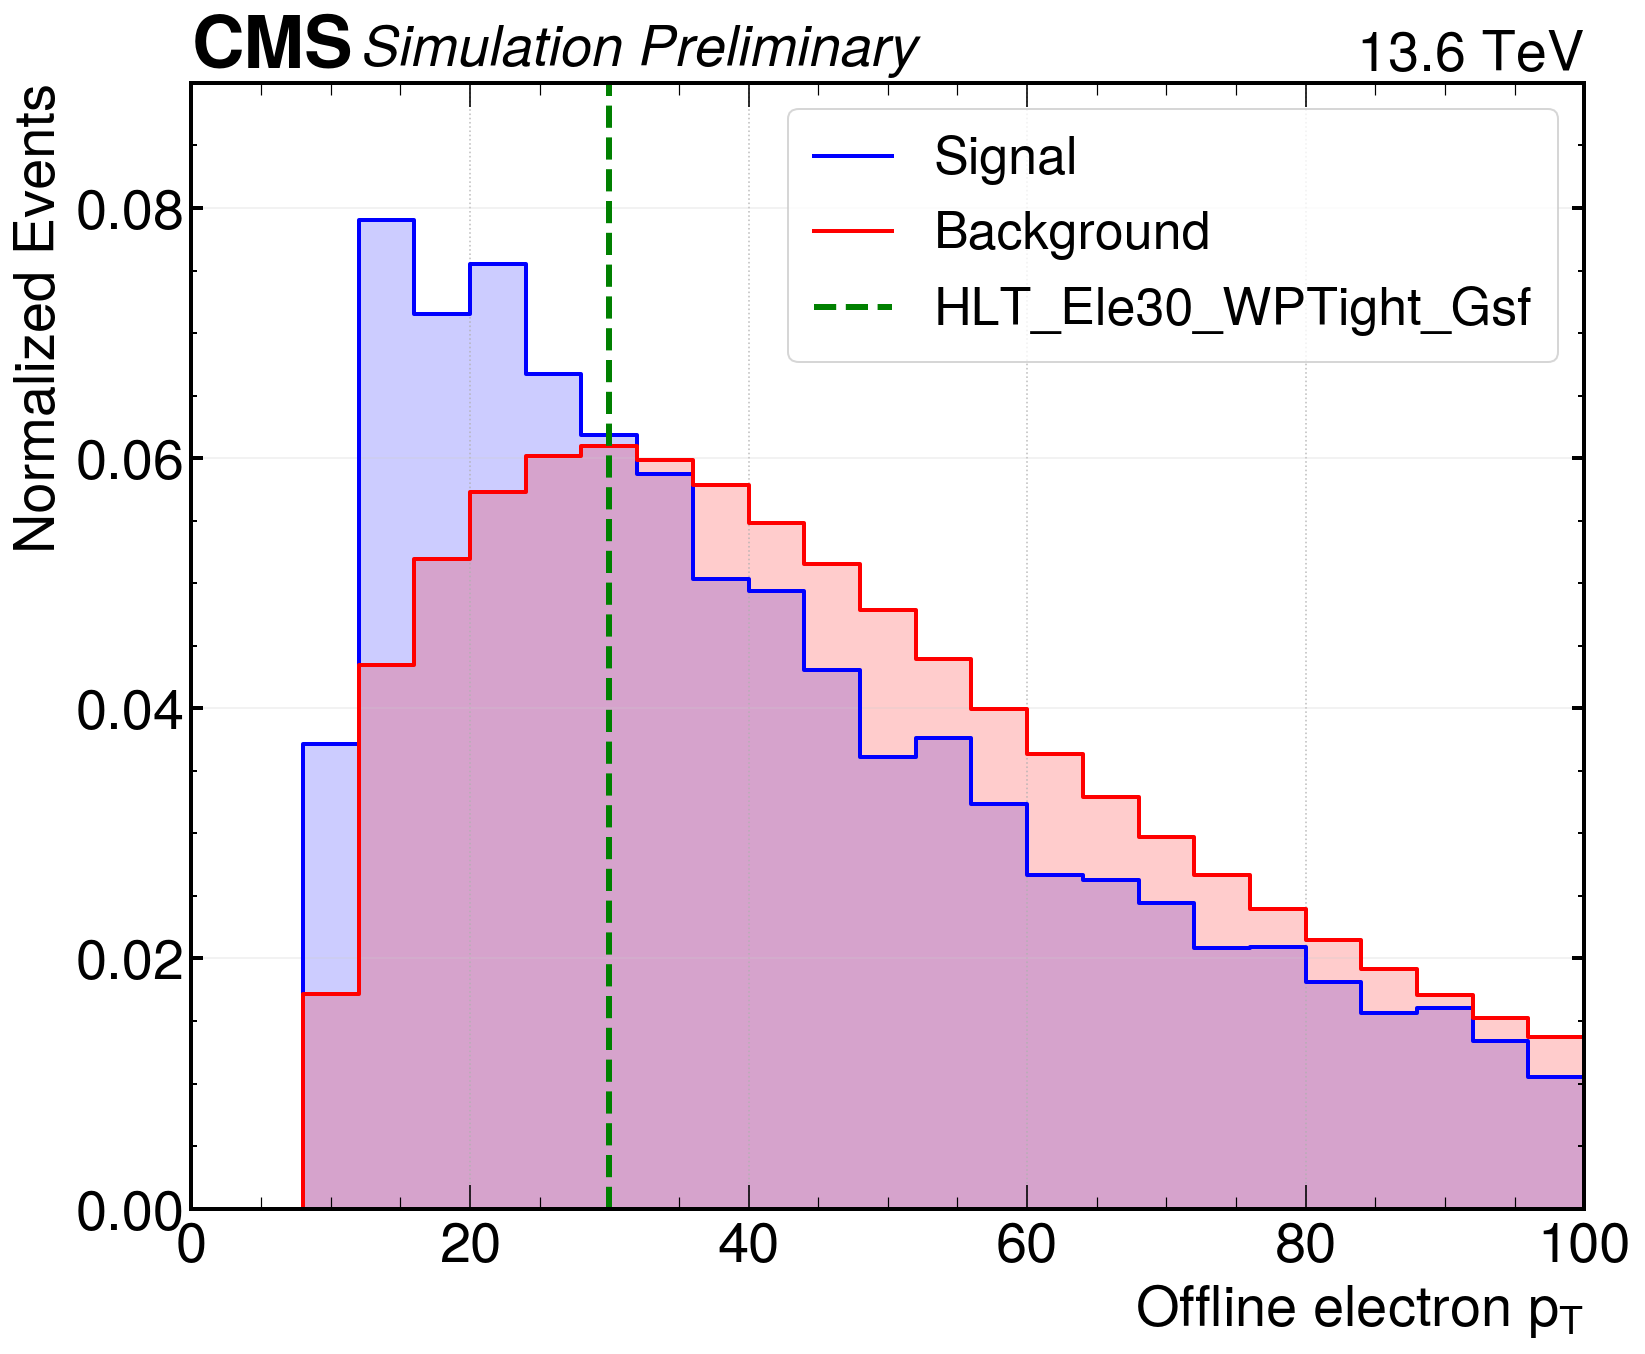

In [29]:
wd = WorkDirectory('/eos/user/a/anunezde/Z_OUTPUT_eos/Triggers_New/2022_LepTop_pt10_noHLT')
analyzer = Analyzer(wd, CONFIG)
fs = 28
plot_style = CMSPlotStyle(figsize=(12,10), label_fs=fs, tick_fs=fs, legend_fs=26, cms_fs=fs)
plot_style.xlabel = 'Offline electron p_{T}'
plot_custom_sig_bkg(analyzer, Reference('SL_e___lep0_pt'), plot_style, PlotLimits(xmin=0, xmax=100, ymin=0,  ymax=0.09), line=30, line_legend='HLT_Ele30_WPTight_Gsf')

Variable detected
$Offline\ muon\ p_{T}$
Figure saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Triggers_New/2022_LepTop_pt10_noHLT/SL_mu___lep0_pt.pdf


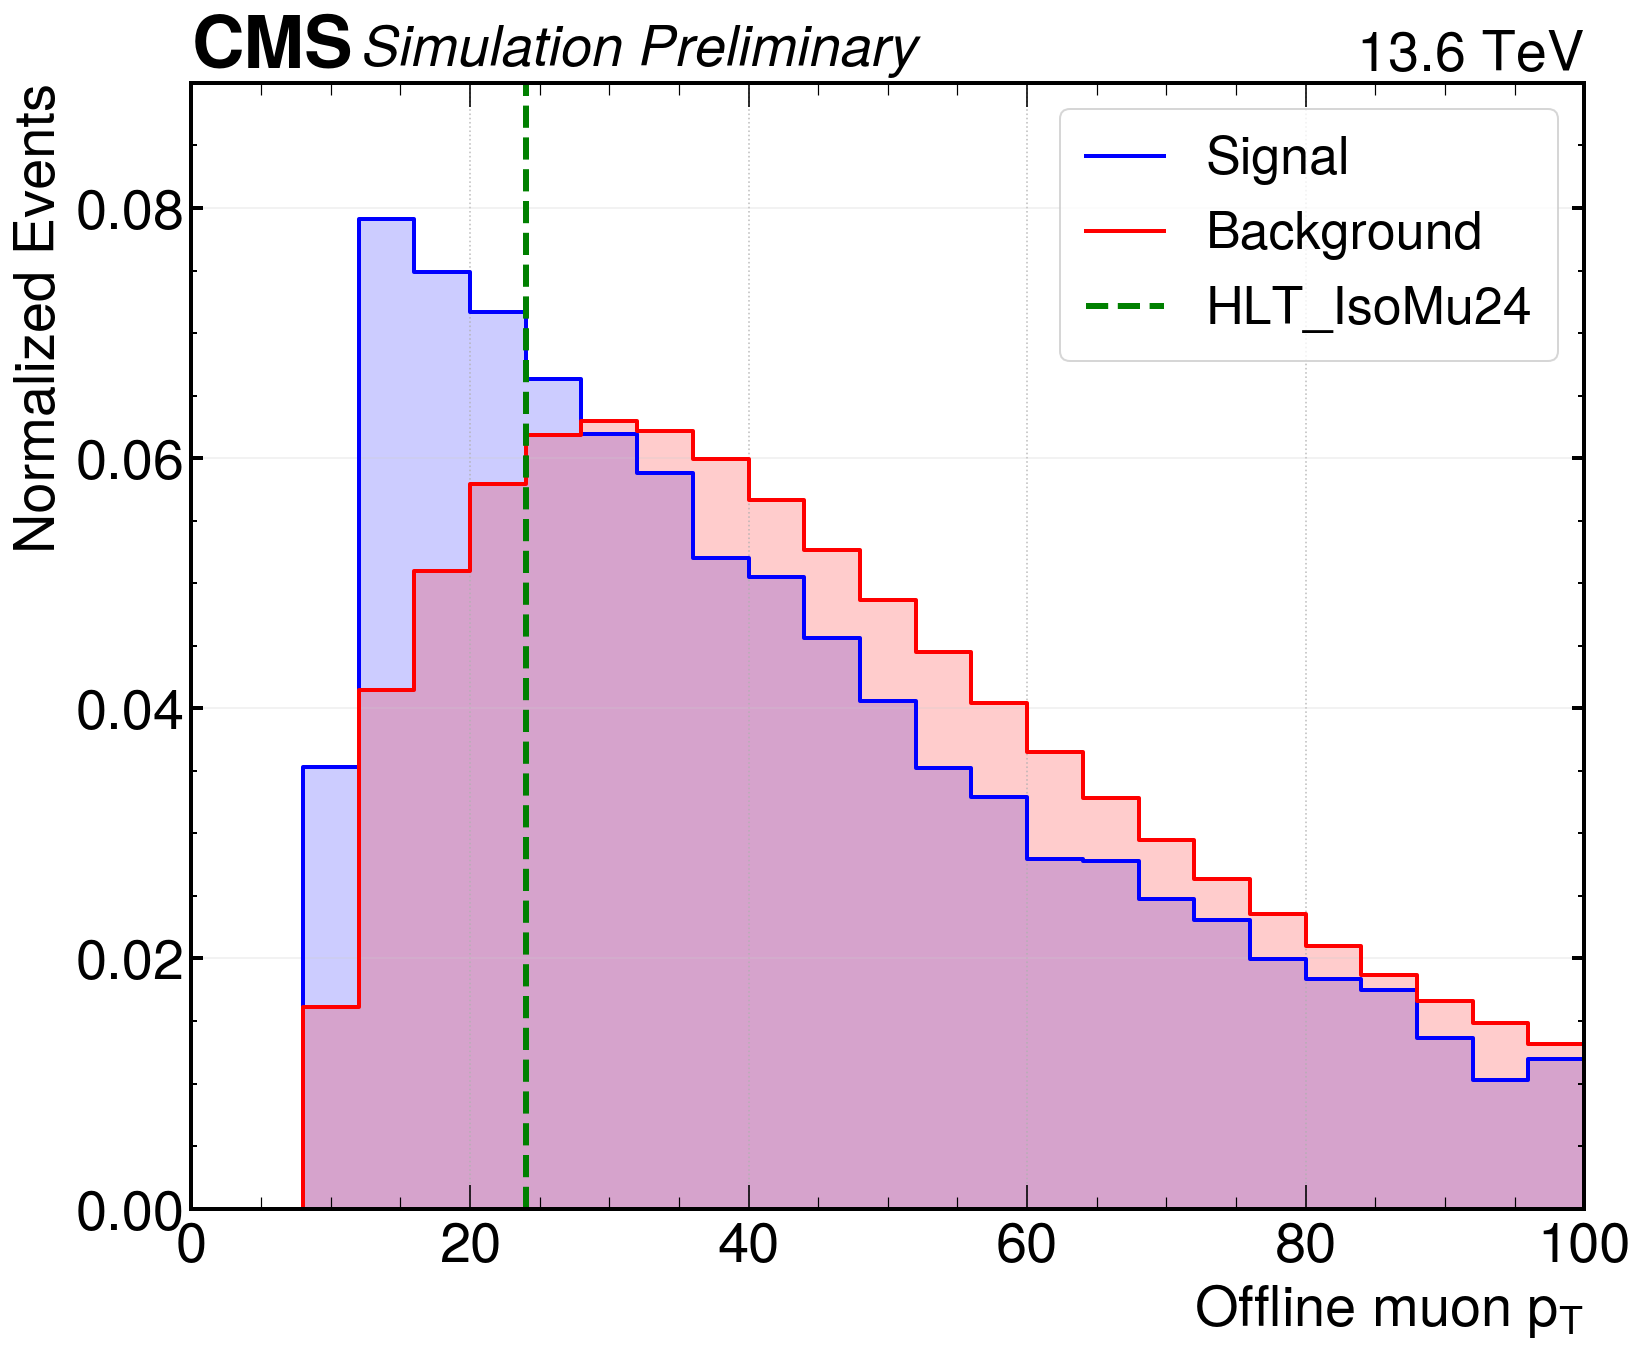

In [32]:
plot_style.xlabel = 'Offline muon p_{T}'
plot_custom_sig_bkg(analyzer, Reference('SL_mu___lep0_pt'), plot_style, PlotLimits(xmin=0, xmax=100, ymin=0,  ymax=0.09), line=24, line_legend='HLT_IsoMu24')